# Simulated Annealing (Tavlama Benzetimi) Algoritması

## 1. Problemin Tanımı
Bir önceki deneyde (Hill Climbing), algoritmamızın **Yerel Optimum (Local Optima)** tuzağına düştüğünü gördük.
- **Mevcut Durum:** Algoritma 200°C'deki küçük tepeye (Skor: 5000) çıkıyor ve orada sıkışıyor.
- **Hedef:** 400°C'deki vadiyi (düşük skoru) göze alıp geçerek, 700°C'deki **Global Optimum** (Skor: 10.000) noktasına ulaşmak.

## 2. Neden Simulated Annealing?
Hill Climbing "Asla daha kötüye gitme" prensibiyle çalışır. Simulated Annealing ise metalurjideki tavlama işleminden esinlenerek:
1. **Yüksek Sıcaklıkta:** Kötü hamleleri kabul etme ihtimali yüksektir (Keşif/Exploration).
2. **Düşük Sıcaklıkta:** Sadece iyi hamleleri kabul eder (Sömürü/Exploitation).

Bu özellik sayesinde algoritma, yerel zirvelerden "aşağı inerek" kurtulabilir.

In [1]:
import random
import math

### Parametreler

In [2]:
temp = 100

In [3]:
T = 1000

In [4]:
cooling_rate = 0.98

In [5]:
min_T = 0.01

In [6]:
def calculateHardness(temp):
    if temp < 400:
        return -1 * (temp - 300)**2 + 5000
    else:
        return -1 * (temp - 500)**2 + 10000

In [7]:
def boltzmann(T, neighbor, current):
    delta = current - neighbor
    return math.exp(- delta / T)

In [8]:
history_temp = []
history_score = []

In [9]:
sayac = 1
while(min_T < T):
    print("Döngü : " , sayac, " Sıcaklık : ", temp)
    print("Fitness : ", calculateHardness(temp))
    print("------")
    current_score = calculateHardness(temp)
    neighbor_temp = temp + random.randint(-110, 110)
    neighbor_score = calculateHardness(neighbor_temp)
    if(neighbor_score > current_score):
        temp = neighbor_temp
    else:
        p = boltzmann(T, neighbor_score, current_score)
        posibilty = random.random()
        if(posibilty < p):
            temp = neighbor_temp
    sayac = sayac+1
    history_temp.append(temp)
    history_score.append(current_score)
    T = T * cooling_rate

Döngü :  1  Sıcaklık :  100
Fitness :  -35000
------
Döngü :  2  Sıcaklık :  122
Fitness :  -26684
------
Döngü :  3  Sıcaklık :  177
Fitness :  -10129
------
Döngü :  4  Sıcaklık :  177
Fitness :  -10129
------
Döngü :  5  Sıcaklık :  186
Fitness :  -7996
------
Döngü :  6  Sıcaklık :  292
Fitness :  4936
------
Döngü :  7  Sıcaklık :  293
Fitness :  4951
------
Döngü :  8  Sıcaklık :  319
Fitness :  4639
------
Döngü :  9  Sıcaklık :  314
Fitness :  4804
------
Döngü :  10  Sıcaklık :  314
Fitness :  4804
------
Döngü :  11  Sıcaklık :  314
Fitness :  4804
------
Döngü :  12  Sıcaklık :  296
Fitness :  4984
------
Döngü :  13  Sıcaklık :  297
Fitness :  4991
------
Döngü :  14  Sıcaklık :  297
Fitness :  4991
------
Döngü :  15  Sıcaklık :  305
Fitness :  4975
------
Döngü :  16  Sıcaklık :  305
Fitness :  4975
------
Döngü :  17  Sıcaklık :  305
Fitness :  4975
------
Döngü :  18  Sıcaklık :  305
Fitness :  4975
------
Döngü :  19  Sıcaklık :  305
Fitness :  4975
------
Döngü :  20 

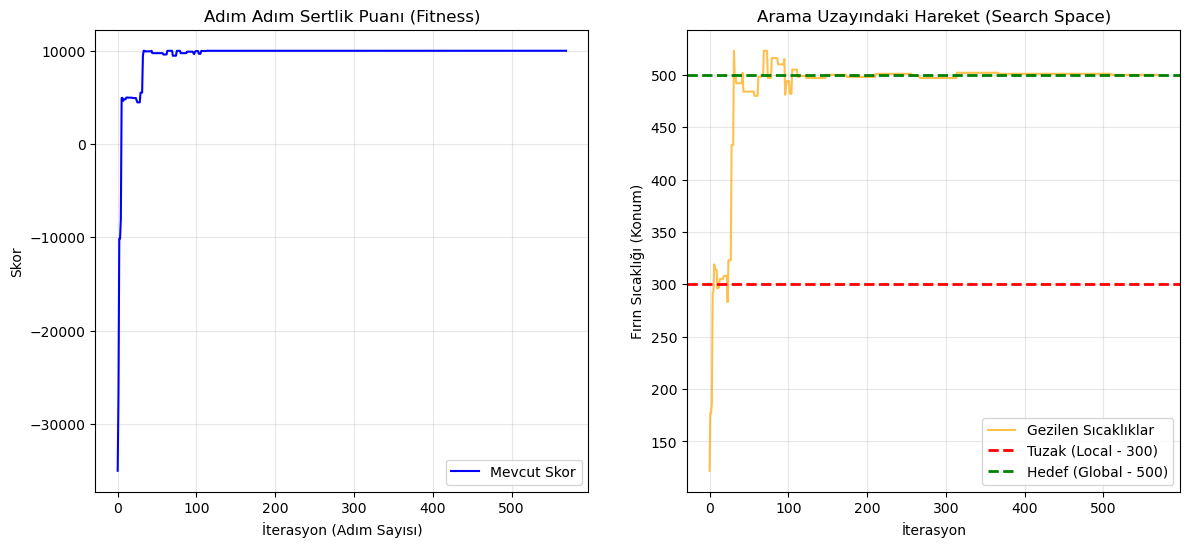

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# GRAFİK 1: Skorun Değişimi (Zamanla ne kadar iyileştik?)
plt.subplot(1, 2, 1)
plt.plot(history_score, color='blue', label='Mevcut Skor')
plt.title("Adım Adım Sertlik Puanı (Fitness)")
plt.xlabel("İterasyon (Adım Sayısı)")
plt.ylabel("Skor")
plt.grid(True, alpha=0.3)
plt.legend()

# GRAFİK 2: Dağcının Rotası (Nerelere uğradık?)
plt.subplot(1, 2, 2)
plt.plot(history_temp, color='orange', alpha=0.7, label='Gezilen Sıcaklıklar')

# Referans Çizgileri (Neresi Tuzak, Neresi Hedef?)
plt.axhline(y=300, color='red', linestyle='--', linewidth=2, label='Tuzak (Local - 300)')
plt.axhline(y=500, color='green', linestyle='--', linewidth=2, label='Hedef (Global - 500)')

plt.title("Arama Uzayındaki Hareket (Search Space)")
plt.xlabel("İterasyon")
plt.ylabel("Fırın Sıcaklığı (Konum)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()